# LEC — Encoding bias: time vs goal progress

Coordinating notebook for the **encoding-bias** package. It runs four analyses
that together adjudicate whether LEC neurons encode *elapsed time* or
*goal progress*, and check that the answer is not an artefact of how the
behavioural variables were binned.

**The concern.** In `glm_analysis_v2`, `time_*` and `distance_*` are quantile-binned
(deciles) while `goal_progress` is equal-width. Quantile binning concentrates a
variable's resolution where its samples are dense, giving it more effective
flexibility. Because time, distance and goal progress are collinear within a leg,
that asymmetry can let time/distance soak up variance that genuinely belongs to
goal progress — biasing GP-tuned cells toward apparent time/distance encoding.
This is compounded by (a) the CPD being computed **in-sample** and (b) the
within-leg **collinearity** of the frames.

**The package (in order of evidential weight).**
1. **Ground-truth simulation** (`encoding_bias_simulation`) — synthesise neurons with
   known tuning and measure how much CPD is *misattributed* under each binning scheme.
2. **Cross-validated CPD across schemes** (`glm_cv_cpd`) — is the descriptive
   time-vs-GP ordering stable once binning is flexibility-fair *and* cross-validated?
3. **De-circularised peak-binning** (`tuning_peak_binning`) — the PI's data-adaptive
   bins, scored without double-dipping.
4. **OOD dissociation** (`time_vs_progress_dissociation`) — the **decisive** test:
   train on short legs, predict held-out long legs. Only duration variability breaks
   the collinearity, so this is what actually adjudicates time vs progress.

See `ENCODING_BIAS.md` for the full rationale.


In [3]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

sys.path.insert(0, os.getcwd())
import glm_analysis_v2 as glm
import glm_cv_cpd as cv
import encoding_bias_simulation as sim
import tuning_peak_binning as pk
import time_vs_progress_dissociation as tvp
import time_vs_progress_report as rep
for m in (glm, cv, sim, pk, tvp, rep):
    reload(m)

glm.apply_gridmaze_style()
REGION = 'LEC'


In [4]:
import pickle
processed_data_folder = "../data/processed_data"
with open(os.path.join(processed_data_folder, 'data_dic_lec.pkl'), 'rb') as f:
    data_dic = pickle.load(f)
mouse_recdays = sorted(k for k in data_dic.keys() if '_sb' not in k)
print(f'{len(mouse_recdays)} {REGION} recdays')
print('first 3:', mouse_recdays[:3])


24 LEC recdays
first 3: [np.str_('ah08_20250613_20250615'), np.str_('ah08_20250616_20250617'), np.str_('ah08_20250618_20250619')]


In [5]:
# Transition-duration filter. The later "*_filtered" GLM sections in
# LEC_glm_tuning_variables / PFC_glm_tuning_variables use 30 s; matching that keeps
# the CPD comparison apples-to-apples with the filtered GLM headline.
# NOTE the trade-off: the standalone dissociation notebook uses 60 s to maximise the
# leg-duration RANGE, which is what powers the OOD test (section 4). Raise this to 60
# if you want maximum OOD power at the cost of GLM comparability.
MAX_TRANSITION_SECONDS = 30
N_RECDAYS = len(mouse_recdays)                      # set to len(mouse_recdays) for the full run
TABLES = tvp.build_design_tables(mouse_recdays[:N_RECDAYS], data_dic,
                                 max_transition_seconds=MAX_TRANSITION_SECONDS)
rep_table = next(iter(TABLES.values()))   # one representative recday for sim / peak-binning
print('recdays in TABLES:', list(TABLES))


Building tables:   0%|          | 0/24 [00:00<?, ?it/s]

Building tables:   4%|▍         | 1/24 [00:01<00:37,  1.61s/it]

  ah08_20250613_20250615: 151 neurons x 10230 samples, 202 legs, has_hd=True


Building tables:   8%|▊         | 2/24 [00:03<00:34,  1.58s/it]

  ah08_20250616_20250617: 164 neurons x 14238 samples, 254 legs, has_hd=True


...

  ly07_20250618_20250619: 88 neurons x 15871 samples, 380 legs, has_hd=True


Building tables:  96%|█████████▌| 23/24 [00:35<00:01,  1.56s/it]

  ly07_20250620_20250623: 89 neurons x 22262 samples, 705 legs, has_hd=True


Building tables: 100%|██████████| 24/24 [00:36<00:00,  1.53s/it]

  ly07_20250624_20250625: 86 neurons x 16697 samples, 621 legs, has_hd=True
recdays in TABLES: [np.str_('ah08_20250613_20250615'), np.str_('ah08_20250616_20250617'), np.str_('ah08_20250618_20250619'), np.str_('ah08_20250620_20250623'), np.str_('ah08_20250624_20250625'), np.str_('ah10_20250613_20250615'), np.str_('ah10_20250616_20250617'), np.str_('ah10_20250618_20250619'), np.str_('ah10_20250620_20250623'), np.str_('ah10_20250624_20250625'), np.str_('ly05_20250613_20250615'), np.str_('ly05_20250616_20250617'), np.str_('ly05_20250618_20250619'), np.str_('ly05_20250624_20250625'), np.str_('ly06_20250613_20250615'), np.str_('ly06_20250616_20250617'), np.str_('ly06_20250618_20250619'), np.str_('ly06_20250620_20250623'), np.str_('ly06_20250624_20250625'), np.str_('ly07_20250613_20250615'), np.str_('ly07_20250616_20250617'), np.str_('ly07_20250618_20250619'), np.str_('ly07_20250620_20250623'), np.str_('ly07_20250624_20250625')]


## 1. Ground-truth simulation — is the binning biased?

Synthetic neurons are tuned to **exactly one** continuous variable (with the real
behavioural sampling), then pushed through the GLM design + CPD under several
schemes. The **misattribution matrix** has rows = true variable, columns =
regressor the CPD landed on. A perfectly unbiased pipeline is diagonal; off-diagonal
mass in the `time-*`/`dist-*` columns of the `GP(t)` row is the bias.

`glm_onehot` reproduces the current (mismatched) GLM; `matched_*` schemes encode
every continuous variable identically (flexibility-fair).


glm_onehot      : GP correct CPD=0.120  leaked->time/dist=0.007  frac correct=0.88
matched_linear  : GP correct CPD=0.132  leaked->time/dist=0.006  frac correct=0.89
matched_quantile: GP correct CPD=0.115  leaked->time/dist=0.007  frac correct=0.87


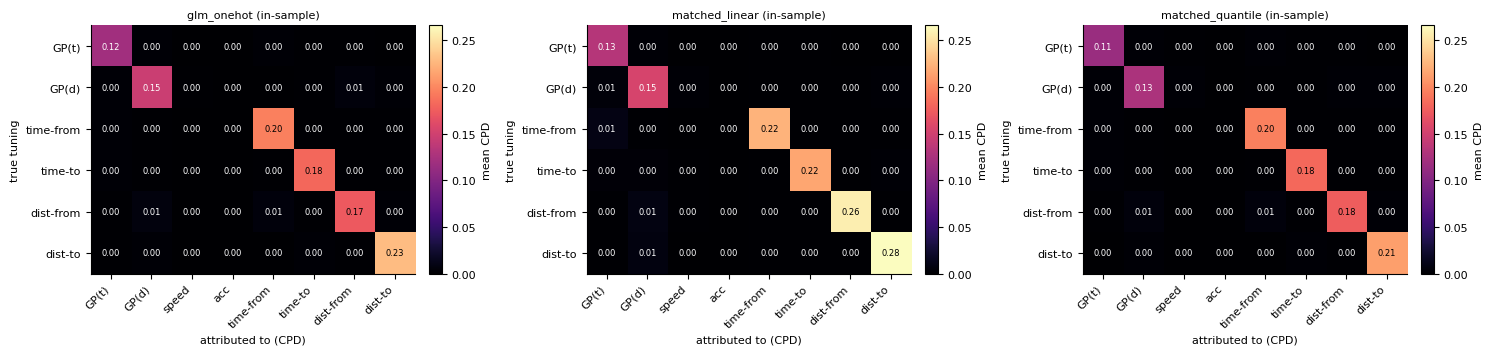

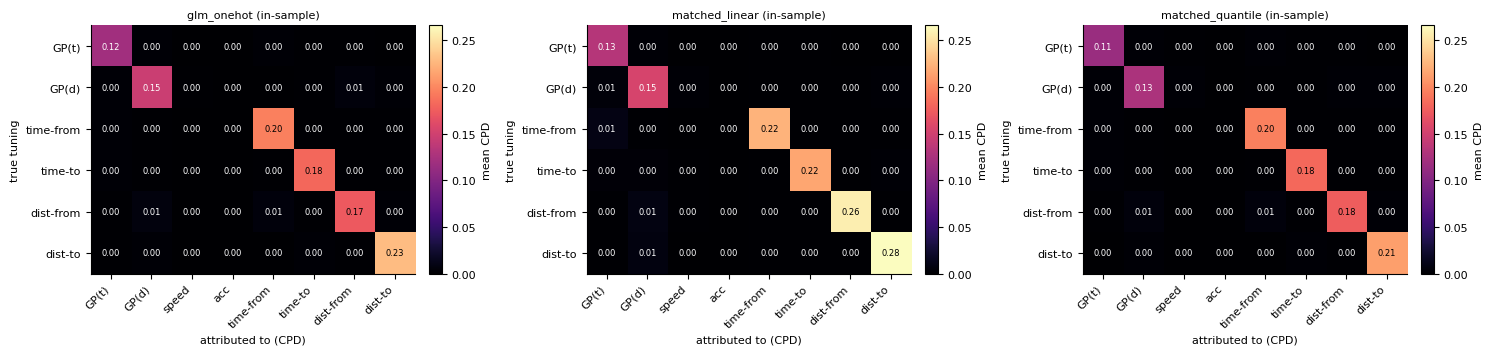

In [6]:
res_sim = sim.run_simulation(
    rep_table, schemes=('glm_onehot', 'matched_linear', 'matched_quantile'),
    cv_folds=0, n_per_cell=20, snr=1.0)
for sc in ('glm_onehot', 'matched_linear', 'matched_quantile'):
    lk = res_sim[sc]['leakage']['goal_progress']
    print(f"{sc:16s}: GP correct CPD={lk['correct_cpd']:.3f}  "
          f"leaked->time/dist={lk['leaked_to_time_distance']:.3f}  "
          f"frac correct={lk['fraction_correct']:.2f}")
res_sim['_figure']


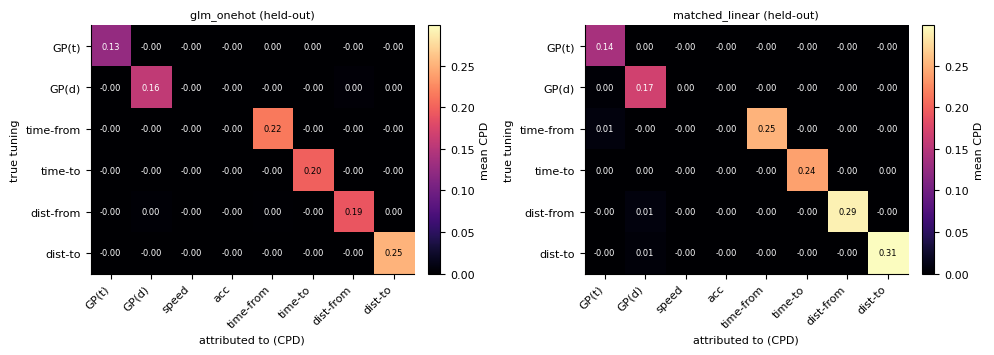

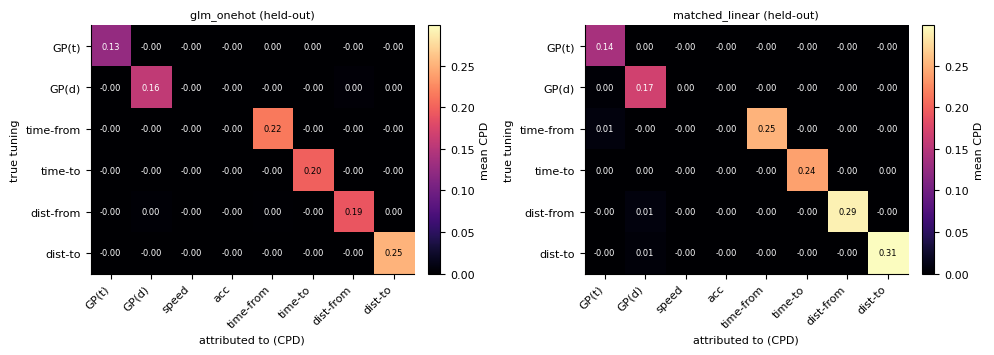

In [7]:
# Cross-validated version: held-out CPD removes the in-sample inflation.
res_sim_cv = sim.run_simulation(
    rep_table, schemes=('glm_onehot', 'matched_linear'),
    cv_folds=5, n_per_cell=15, snr=1.0)
res_sim_cv['_figure']


## 2. Cross-validated CPD across encoding schemes (robustness)

Real neurons now. If the descriptive `GP - time` contrast **flips sign** across
schemes, the original in-sample CPD ordering was a binning artefact and only the
OOD test (section 4) should be trusted. Stable bars => the descriptive result is
robust.



=== scheme: glm_onehot ===
  ah08_20250613_20250615: 151 neurons, median full-model held-out R^2 = -0.011
  ah08_20250616_20250617: 164 neurons, median full-model held-out R^2 = -0.005
  ah08_20250618_20250619: 183 neurons, median full-model held-out R^2 = -0.004
  ah08_20250620_20250623: 108 neurons, median full-model held-out R^2 = -0.002
  ah08_20250624_20250625: 186 neurons, median full-model held-out R^2 = -0.024
  ah10_20250613_20250615: 139 neurons, median full-model held-out R^2 = 0.007
  ah10_20250616_20250617: 154 neurons, median full-model held-out R^2 = 0.007
  ah10_20250618_20250619: 162 neurons, median full-model held-out R^2 = 0.006
  ah10_20250620_20250623: 153 neurons, median full-model held-out R^2 = 0.011
  ah10_20250624_20250625: 164 neurons, median full-model held-out R^2 = 0.012
  ly05_20250613_20250615: 117 neurons, median full-model held-out R^2 = -0.003
  ly05_20250616_20250617: 116 neurons, median full-model held-out R^2 = -0.001
  ly05_20250618_20250619: 91 

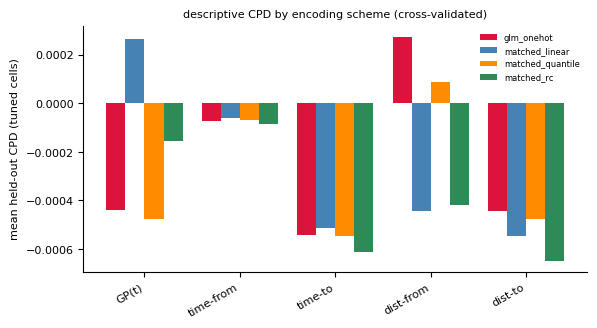

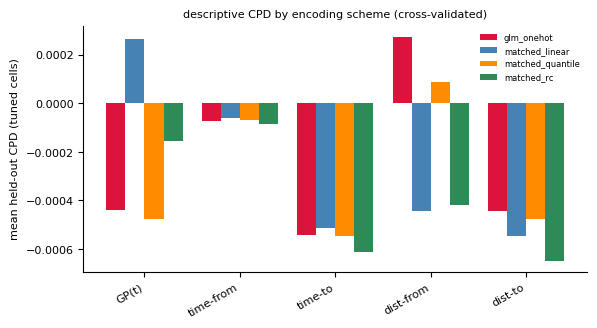

In [8]:
pooled_by_scheme, summary = rep.compare_schemes_cpd(
    TABLES, schemes=('glm_onehot', 'matched_linear', 'matched_quantile', 'matched_rc'),
    n_folds=5)
# Per-sample single-neuron held-out CPD is ~0 for untuned cells, so we summarise the
# TUNED subpopulation (full-model held-out R^2 > 0) plus the all-neuron mean.
for s in summary:
    print(f"{s['scheme']:16s}: tuned={s['frac_tuned']:.0%}  GP={s['GP_tuned']:.3f}  "
          f"time={s['time_tuned']:.3f}  dist={s['dist_tuned']:.3f}  "
          f"GP-time(tuned)={s['GP_minus_time_tuned']:+.3f}  "
          f"GP-time(mean)={s['GP_minus_time_mean']:+.4f}")
rep.plot_scheme_comparison(pooled_by_scheme)
plt.gcf()


## 3. peak-binning, de-circularised

Bins are placed where the **population tuning changes fastest** (robust to ramps),
derived on one half of the legs and scored on the other half — so no sample informs
both its own bins and its own CPD. The red lines show where resolution was placed;
the grey histogram is the PI's original 'peak' (argmax) distribution.


de-circularised peak-binning: median GP CPD=-0.002  time CPD=-0.002  GP-time=-0.000


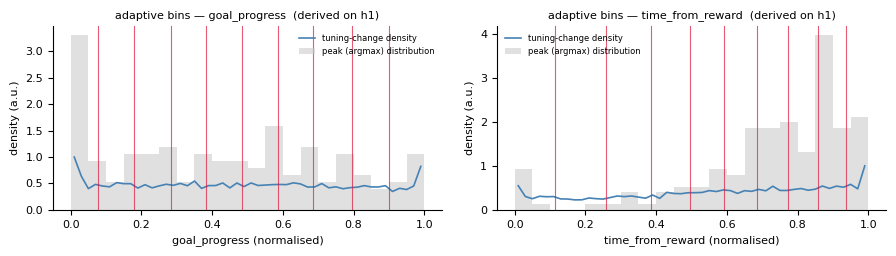

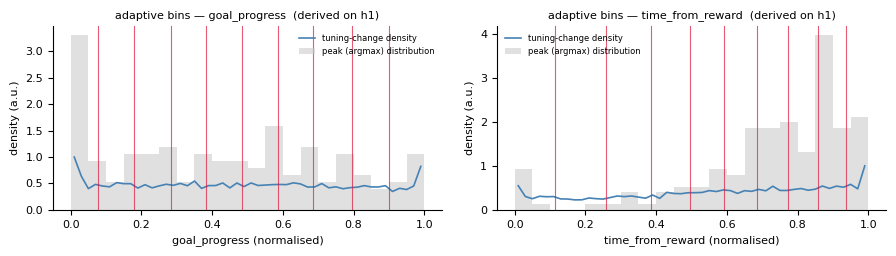

In [9]:
pb = pk.run_peak_binning(rep_table, n_bins=10, n_folds=5)
gp = np.nanmedian(pb['cpd']['goal_progress'])
tt = np.nanmedian(np.nanmax(np.vstack([pb['cpd']['time_from_reward'],
                                       pb['cpd']['time_to_reward']]), axis=0))
print(f"de-circularised peak-binning: median GP CPD={gp:.3f}  time CPD={tt:.3f}  GP-time={gp-tt:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
pk.plot_adaptive_bins(pb['diag'], 'goal_progress', ax=axes[0], half='h1')
pk.plot_adaptive_bins(pb['diag'], 'time_from_reward', ax=axes[1], half='h1')
fig.tight_layout()
fig


## 4. Adjudicating test: OOD dissociation + full report

`build_report` runs the OOD dissociation (decisive) and assembles it with the
CPD-by-scheme robustness into one figure + printed headline. The OOD median delta
is the answer: **>0 leans elapsed time, <0 leans goal progress**.


OOD temporal/gaussian: 100%|██████████| 24/24 [16:07<00:00, 40.33s/it]



=== scheme: glm_onehot ===
  ah08_20250613_20250615: 151 neurons, median full-model held-out R^2 = -0.011
  ah08_20250616_20250617: 164 neurons, median full-model held-out R^2 = -0.005
  ah08_20250618_20250619: 183 neurons, median full-model held-out R^2 = -0.004
  ah08_20250620_20250623: 108 neurons, median full-model held-out R^2 = -0.002
  ah08_20250624_20250625: 186 neurons, median full-model held-out R^2 = -0.024
  ah10_20250613_20250615: 139 neurons, median full-model held-out R^2 = 0.007
  ah10_20250616_20250617: 154 neurons, median full-model held-out R^2 = 0.007
  ah10_20250618_20250619: 162 neurons, median full-model held-out R^2 = 0.006
  ah10_20250620_20250623: 153 neurons, median full-model held-out R^2 = 0.011
  ah10_20250624_20250625: 164 neurons, median full-model held-out R^2 = 0.012
  ly05_20250613_20250615: 117 neurons, median full-model held-out R^2 = -0.003
  ly05_20250616_20250617: 116 neurons, median full-model held-out R^2 = -0.001
  ly05_20250618_20250619: 91 

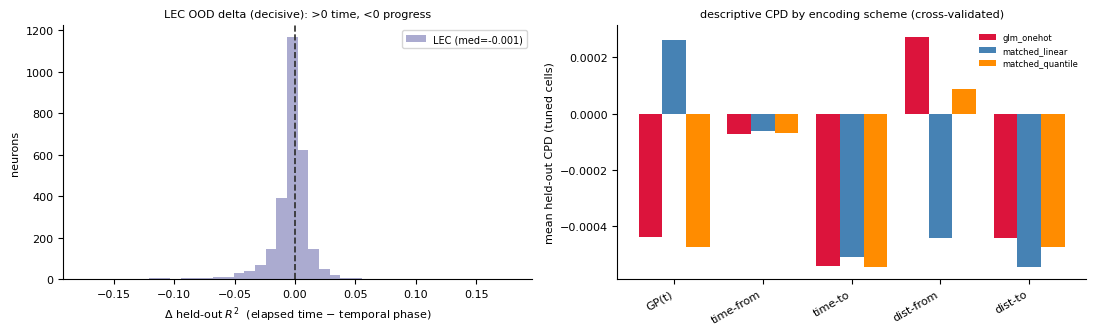

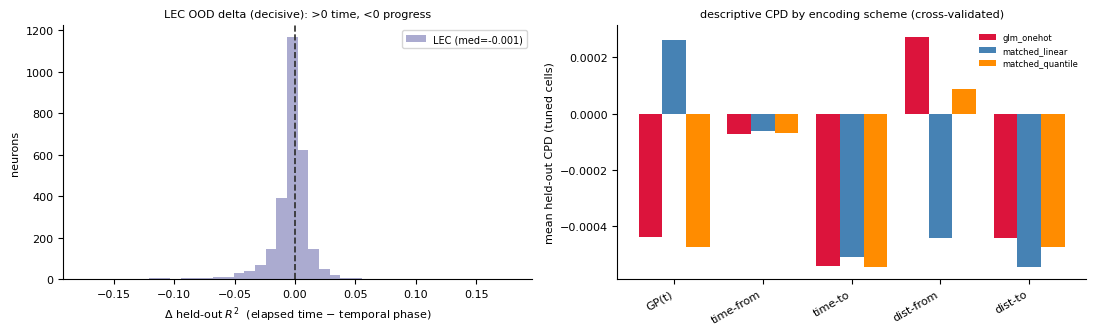

In [10]:
report = rep.build_report(
    TABLES, region=REGION, contrast='temporal',
    schemes=('glm_onehot', 'matched_linear', 'matched_quantile'),
    run_simulation=True, run_peak_binning=True, n_folds=5)
report['figure']


### How to read these results

- **OOD delta (section 4) is the verdict.** A median delta significantly >0 means
  cells generalise as *fixed-latency time* across durations; <0 means *goal progress*.
- **CPD-by-scheme (section 2) is descriptive.** Use it only to check robustness: if
  `GP - time` is stable across `glm_onehot` and the `matched_*` schemes, the
  descriptive ordering is not a binning artefact. If it flips, defer entirely to OOD.
- **Simulation (section 1)** tells you the *direction and size* of the binning bias
  for this dataset's sampling. Compare the `glm_onehot` matrix (expected off-diagonal
  GP->time leak) with the `matched_*` matrices (should be more diagonal).
- **Peak-binning (section 3)** implements the PI's idea without circularity; treat it
  as one more robustness scheme, not as the adjudicator.

Run the full set (`N_RECDAYS = len(mouse_recdays)`) before interpreting for the paper.
